# Validation & Robustness (Task A1) — response to Reviewer 1

Reviewer 1's main concern: consecutive samples from the same attack episode are
correlated, so the evaluation should (a) use group-based/temporally-blocked splits with
nested CV — done in `02_final_comparison.ipynb` / `src/eval_protocol.py` — (b) **reserve
independent attack sessions for a final, locked test set**, and (c) ideally repeat the
field experiment on different days/sites. No new field experiment is possible; this
notebook covers everything that *can* be done with the existing `data/rssi_raw.csv`:

| # | What it answers | Section |
|---|---|---|
| V1 | independent sessions held out for final testing, never touched by model selection | locked hold-out (temporal block + balanced session design) |
| V2 | closest available substitute for leave-one-day-out | forward-chaining (train on the past, test on a later time block) |
| V3 | why sample-level splitting leaks | within-session dependence (autocorrelation vs. ICC) |
| V4 | uncertainty on every headline number | cluster (session-level) bootstrap CIs |
| V5 | effective sample size / benefit of temporal aggregation, detection sensitivity | session-level & sliding-window majority vote |
| V6 | is antenna/point identification above chance at all | session-level permutation test |
| V7 | is the sample count inflated by imputation | no-imputation sensitivity variants (dropna 5s grid + scan-cycle alignment) |
| F5 | localization error in metres | from the Point Prediction OOF predictions |

Builds on `src/eval_protocol.py` (same module as `02_final_comparison.ipynb`) and reuses
`results/table1_primary.csv` / `results/best_params.csv` from that notebook, which must
be run first.

**Revision note (review_1, commit a808a00 follow-up):** F1 fixes V1's model choice so it
never sees the held-out test data (it was previously reusing the *global* main-table
winner, which itself was cross-validated over the same blocks/sessions V1 holds out).
F2 implements V7's scan-cycle alignment option instead of only the `dropna()` grid
variant. F3 adds detection-sensitivity numbers (detection rate, delay, recall) next to
the false-alarm rate. F4 adds paper-ready (untitled) figure variants. F5 adds
localization error in metres.

## 1. Imports & Configuration

In [1]:
import sys, time, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import eval_protocol as ep

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 320,
    'savefig.dpi': 320,
})

REPO_ROOT = ep._find_repo_root()
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = REPO_ROOT / "figures"
INTERNAL_FIGURES_DIR = FIGURES_DIR / "internal"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
INTERNAL_FIGURES_DIR.mkdir(exist_ok=True)

table1_df = pd.read_csv(RESULTS_DIR / "table1_primary.csv", index_col="Model")
best_params_df = pd.read_csv(RESULTS_DIR / "best_params.csv")
print("Loaded table1_primary.csv and best_params.csv from 02_final_comparison.ipynb")

Loaded table1_primary.csv and best_params.csv from 02_final_comparison.ipynb


## 2. Load Dataset

Same pipeline as `02_final_comparison.ipynb` (5s grid, nearest-value imputation, FE
features) — `src/eval_protocol.py` is the single source of truth for both notebooks.
`TASK_WINNERS` (the *global* main-table winner per task) is used for V2/V4/V5/V7/F5 —
those sections have no separate locked test set of their own, so reusing the
cross-validated main-table winner is not a leak. V1 does **not** use `TASK_WINNERS`
(see F1 in section 3) because it has an explicit reserved test set.

In [2]:
raw = ep.load_raw()
dataset, info = ep.build_dataset(raw, freq="5s")
dataset = ep.add_fe(dataset)

assert info.n_rows == 2131 and info.n_attack_rows == 571 and info.n_sessions_attack == 48
print(f"Dataset: {info.n_rows} rows, {info.n_attack_rows} attack rows, {info.n_sessions_attack} attack sessions")

TASK_WINNERS = {}
for task in ep.TASKS_ORDER:
    task_label = ep.TASKS[task]["label"]
    best_val, best_key = -1, None
    for fs_label, fs_col in [("Base (4)", "Base"), ("FE (13)", "FE")]:
        for model in ep.MODEL_CONFIGS:
            v = table1_df.loc[model, f"{task_label} Pooled Acc ({fs_col})"]
            if v > best_val:
                best_val, best_key = v, (model, fs_label)
    TASK_WINNERS[task] = best_key
    print(f"{task_label:<22} global winner={best_key[0]} ({best_key[1]}) pooled_acc={best_val:.4f}")

Dataset: 2131 rows, 571 attack rows, 48 attack sessions
Attack Detection       global winner=KNN (Base (4)) pooled_acc=0.9883
Point Prediction       global winner=KNN (FE (13)) pooled_acc=0.7426
Antenna Prediction     global winner=XGBoost (Base (4)) pooled_acc=0.3625


## 3. V1 — Locked Final Test Set

Two hold-out designs, neither used for any tuning/feature-selection/model choice. Fixed
feature set: **FE (13)** for tractability.

**F1 fix:** the model reported as "the winning model" for each design is now selected
using **nested-CV pooled accuracy computed entirely on the dev split** —
`eval_protocol.select_best_model_on_dev`, which takes no test-set argument at all, so it
cannot see the held-out rows by construction. All 9 models are still evaluated on the
locked test set and reported in `final_holdout.csv`; the model chosen by the dev-only
ranking is flagged in a new `selected_on_dev` column. The acceptance-check assertion
that test sessions never touch model selection lives in `locked_holdout_eval`
(`assert_no_session_overlap`, called before anything else) — every `locked_holdout_eval`
call below uses it.

### V1a — temporal hold-out: last antenna block (block 6)

Dev = blocks 1-5 (antennas 1-5). Test = block 6 (APA-M04, ~17:05-17:30, incl. its
attack-free gaps) — an unseen antenna **and** a later time block at once. Antenna
Prediction is not evaluated here: the held-out antenna is unseen by construction.

In [3]:
FS_V1 = "FE (13)"
feat_cols_v1 = ep.FEATURES_FE

dev_mask_a = dataset["block"] <= 5
test_mask_a = dataset["block"] == 6

v1a_rows = []
v1a_dev_scores = {}  # task -> {model: dev_pooled_acc}
for task in ["attack", "point"]:
    spec = ep.TASKS[task]
    task_label = spec["label"]
    is_multiclass = task != "attack"
    group_col = ep.PROTOCOLS["primary"].group_col_by_task[task]

    row_mask = spec["rows"](dataset)
    dev_mask = row_mask & dev_mask_a
    test_mask = row_mask & test_mask_a

    X_dev = dataset.loc[dev_mask, feat_cols_v1]
    y_dev = dataset.loc[dev_mask, spec["y_col"]]
    groups_dev = dataset.loc[dev_mask, group_col].to_numpy()
    sessions_dev = dataset.loc[dev_mask, "session"].to_numpy()

    X_test = dataset.loc[test_mask, feat_cols_v1]
    y_test = dataset.loc[test_mask, spec["y_col"]]
    sessions_test = dataset.loc[test_mask, "session"].to_numpy()

    # F1: rank models on dev only (no X_test/sessions_test passed in at all)
    t0 = time.time()
    best_on_dev, dev_scores = ep.select_best_model_on_dev(task, X_dev, y_dev, groups_dev, is_multiclass=is_multiclass)
    v1a_dev_scores[task] = dev_scores
    print(f"[V1a dev-ranking] {task_label:<20} selected_on_dev={best_on_dev} "
          f"(dev pooled_acc={dev_scores[best_on_dev]:.3f}) ({time.time()-t0:.1f}s)")

    for model_name in ep.MODEL_CONFIGS:
        t0 = time.time()
        res = ep.locked_holdout_eval(
            model_name, X_dev, y_dev, groups_dev, sessions_dev,
            X_test, y_test, sessions_test, is_multiclass=is_multiclass, task=task,
        )
        ci = ep.cluster_bootstrap_ci(y_test.to_numpy(), res["y_pred"], sessions_test, n_boot=2000, seed=0)
        v1a_rows.append({
            "task": task_label, "design": "V1a temporal (block 6 held out)", "model": model_name,
            "selected_on_dev": model_name == best_on_dev, "dev_pooled_acc": dev_scores[model_name],
            "accuracy": res["pooled_acc"], "macro_f1": res["macro_f1"],
            "precision": res.get("precision"), "recall": res.get("recall"), "fpr": res.get("fpr"),
            "n_test_rows": res["n_test_rows"], "n_test_sessions": res["n_test_sessions"],
            "ci_low": ci["ci_low"], "ci_high": ci["ci_high"],
        })
        print(f"[V1a] {task_label:<20} {model_name:<20} acc={res['pooled_acc']:.3f} ({time.time()-t0:.1f}s)")

print(f"\nV1a done: {len(v1a_rows)} rows")

[V1a dev-ranking] Attack Detection     selected_on_dev=CatBoost (dev pooled_acc=0.989) (125.7s)


[V1a] Attack Detection     Logistic Regression  acc=0.991 (5.3s)


[V1a] Attack Detection     SVM (RBF)            acc=0.991 (0.7s)


[V1a] Attack Detection     KNN                  acc=0.988 (1.2s)


[V1a] Attack Detection     Decision Tree        acc=0.988 (0.7s)


...

[V1a] Point Prediction     Random Forest        acc=0.848 (7.5s)


[V1a] Point Prediction     Extra Trees          acc=0.848 (5.6s)


[V1a] Point Prediction     XGBoost              acc=0.818 (2.8s)


[V1a] Point Prediction     LightGBM             acc=0.808 (2.6s)


[V1a] Point Prediction     CatBoost             acc=0.848 (81.9s)

V1a done: 18 rows


### V1b — balanced session hold-out

8 attack sessions, one per point, antenna assigned by the fixed rule
`antenna = ((point-1) mod 6) + 1` (a Latin-style design covering every point once and
every antenna at least once), plus each selected session's preceding attack-free gap.
Saved to `results/v1b_test_sessions.csv`. All three tasks are evaluated here; model
selection is again dev-only (the 40 dev sessions), per F1.

In [4]:
v1b_sessions = ep.select_balanced_holdout_sessions(raw)
v1b_sessions.to_csv(RESULTS_DIR / "v1b_test_sessions.csv", index=False)
print(v1b_sessions)

test_session_ids = set(v1b_sessions["session"]) | set(v1b_sessions["gap_session"])
test_mask_b = dataset["session"].isin(test_session_ids)
dev_mask_b = ~test_mask_b

v1b_rows = []
v1b_dev_scores = {}
for task in ep.TASKS_ORDER:
    spec = ep.TASKS[task]
    task_label = spec["label"]
    is_multiclass = task != "attack"
    group_col = ep.PROTOCOLS["primary"].group_col_by_task[task]

    row_mask = spec["rows"](dataset)
    dev_mask = row_mask & dev_mask_b
    test_mask = row_mask & test_mask_b

    X_dev = dataset.loc[dev_mask, feat_cols_v1]
    y_dev = dataset.loc[dev_mask, spec["y_col"]]
    groups_dev = dataset.loc[dev_mask, group_col].to_numpy()
    sessions_dev = dataset.loc[dev_mask, "session"].to_numpy()

    X_test = dataset.loc[test_mask, feat_cols_v1]
    y_test = dataset.loc[test_mask, spec["y_col"]]
    sessions_test = dataset.loc[test_mask, "session"].to_numpy()

    t0 = time.time()
    best_on_dev, dev_scores = ep.select_best_model_on_dev(task, X_dev, y_dev, groups_dev, is_multiclass=is_multiclass)
    v1b_dev_scores[task] = dev_scores
    print(f"[V1b dev-ranking] {task_label:<20} selected_on_dev={best_on_dev} "
          f"(dev pooled_acc={dev_scores[best_on_dev]:.3f}) ({time.time()-t0:.1f}s)")

    for model_name in ep.MODEL_CONFIGS:
        t0 = time.time()
        res = ep.locked_holdout_eval(
            model_name, X_dev, y_dev, groups_dev, sessions_dev,
            X_test, y_test, sessions_test, is_multiclass=is_multiclass, task=task,
        )
        ci = ep.cluster_bootstrap_ci(y_test.to_numpy(), res["y_pred"], sessions_test, n_boot=2000, seed=0)
        v1b_rows.append({
            "task": task_label, "design": "V1b balanced session hold-out", "model": model_name,
            "selected_on_dev": model_name == best_on_dev, "dev_pooled_acc": dev_scores[model_name],
            "accuracy": res["pooled_acc"], "macro_f1": res["macro_f1"],
            "precision": res.get("precision"), "recall": res.get("recall"), "fpr": res.get("fpr"),
            "n_test_rows": res["n_test_rows"], "n_test_sessions": res["n_test_sessions"],
            "ci_low": ci["ci_low"], "ci_high": ci["ci_high"],
        })
        print(f"[V1b] {task_label:<20} {model_name:<20} acc={res['pooled_acc']:.3f} ({time.time()-t0:.1f}s)")

print(f"\nV1b done: {len(v1b_rows)} rows")

final_holdout_df = pd.DataFrame(v1a_rows + v1b_rows)
final_holdout_df.to_csv(RESULTS_DIR / "final_holdout.csv", index=False)
final_holdout_df.round(4)

   point  antenna  session  gap_session
0      1        1        2            1
1      2        2       20           19
2      3        3       38           37
3      4        4       56           55
4      5        5       74           73
5      6        6       92           91
6      7        1       14           13
7      8        2       32           31


[V1b dev-ranking] Attack Detection     selected_on_dev=KNN (dev pooled_acc=0.988) (265.8s)


[V1b] Attack Detection     Logistic Regression  acc=0.987 (4.4s)


[V1b] Attack Detection     SVM (RBF)            acc=0.985 (0.5s)


[V1b] Attack Detection     KNN                  acc=0.985 (0.8s)


...

[V1b] Antenna Prediction   Extra Trees          acc=0.213 (4.5s)


[V1b] Antenna Prediction   XGBoost              acc=0.191 (2.4s)


[V1b] Antenna Prediction   LightGBM             acc=0.170 (1.9s)


[V1b] Antenna Prediction   CatBoost             acc=0.181 (25.0s)

V1b done: 27 rows


,task,design,model,selected_on_dev,dev_pooled_acc,accuracy,macro_f1,precision,recall,fpr,n_test_rows,n_test_sessions,ci_low,ci_high
0,Attack Detection,V1a temporal (block 6 held out),Logistic Regression,False,0.9849,0.9912,0.9893,0.9898,0.9798,0.0041,340,17,0.9792,1.0000
1,Attack Detection,V1a temporal (block 6 held out),SVM (RBF),False,0.9866,0.9912,0.9893,0.9898,0.9798,0.0041,340,17,0.9792,1.0000
2,Attack Detection,V1a temporal (block 6 held out),KNN,False,0.9883,0.9882,0.9857,0.9897,0.9697,0.0041,340,17,0.9703,1.0000
3,Attack Detection,V1a temporal (block 6 held out),Decision Tree,False,0.9860,0.9882,0.9857,0.9897,0.9697,0.0041,340,17,0.9743,0.9973
4,Attack Detection,V1a temporal (block 6 held out),Random Forest,False,0.9877,0.9912,0.9893,0.9898,0.9798,0.0041,340,17,0.9792,1.0000
5,Attack Detection,V1a temporal (block 6 held out),Extra Trees,False,0.9877,0.9912,0.9893,0.9898,0.9798,0.0041,340,17,0.9792,1.0000
6,Attack Detection,V1a temporal (block 6 held out),XGBoost,False,0.9866,0.9912,0.9893,0.9898,0.9798,0.0041,340,17,0.9792,1.0000
7,Attack Detection,V1a temporal (block 6 held out),LightGBM,False,0.9849,0.9912,0.9893,0.9898,0.9798,0.0041,340,17,0.9792,1.0000
8,Attack Detection,V1a temporal (block 6 held out),CatBoost,True,0.9894,0.9912,0.9893,0.9898,0.9798,0.0041,340,17,0.9792,1.0000
9,Point Prediction,V1a temporal (block 6 held out),Logistic Regression,False,0.6907,0.8889,0.8894,NaN,NaN,NaN,99,8,0.7961,0.9691


In [5]:
# Headline: the model actually selected_on_dev per design/task
v1_selected = final_holdout_df[final_holdout_df["selected_on_dev"]][
    ["task", "design", "model", "dev_pooled_acc", "accuracy", "macro_f1", "ci_low", "ci_high", "n_test_rows", "n_test_sessions"]
].reset_index(drop=True)
print("V1 headline (model selected on dev-only nested CV, never on the held-out test set):")
v1_selected.round(4)

V1 headline (model selected on dev-only nested CV, never on the held-out test set):


,task,design,model,dev_pooled_acc,accuracy,macro_f1,ci_low,ci_high,n_test_rows,n_test_sessions
0,Attack Detection,V1a temporal (block 6 held out),CatBoost,0.9894,0.9912,0.9893,0.9792,1.0000,340,17
1,Point Prediction,V1a temporal (block 6 held out),KNN,0.7182,0.8384,0.8416,0.7245,0.9381,99,8
2,Attack Detection,V1b balanced session hold-out,KNN,0.9880,0.9850,0.9766,0.9624,0.9955,467,16
3,Point Prediction,V1b balanced session hold-out,CatBoost,0.7107,0.7660,0.7526,0.6044,0.9193,94,8
4,Antenna Prediction,V1b balanced session hold-out,CatBoost,0.2495,0.1809,0.1609,0.0215,0.3957,94,8


## 4. V2 — Forward-Chaining Evaluation

Substitute for leave-one-day-out: for test block *b* = 2..6, train only on blocks
*< b* (an expanding window, no future information) and test on block *b*. Attack and
Point only (Antenna's test antenna is always unseen by construction). Uses **fixed**
hyperparameters — the most frequent `best_params_` from the main task's primary-protocol
outer folds (`eval_protocol.mode_best_params`) — for each task's overall winning
model/feature-set (`TASK_WINNERS`, the main-table nested-CV winner — no separate reserved
test set exists here, so this is not a F1-style leak), to avoid re-tuning 5 times.

In [6]:
BLOCK_ANTENNA_NAMES = {1: "ARS-N05", 2: "ARS-N19", 3: "APA-M25", 4: "Yagi", 5: "Logperiodic", 6: "APA-M04"}

fc_rows = []
for task in ["attack", "point"]:
    spec = ep.TASKS[task]
    task_label = spec["label"]
    is_multiclass = task != "attack"
    model_name, fs_label = TASK_WINNERS[task]
    feat_cols = ep.FEATURES_BASE if fs_label.startswith("Base") else ep.FEATURES_FE
    fixed_params = ep.mode_best_params(best_params_df, model_name, task_label, fs_label)

    row_mask = spec["rows"](dataset)

    for b in range(2, 7):
        train_mask = row_mask & (dataset["block"] < b)
        test_mask = row_mask & (dataset["block"] == b)
        ep.assert_no_session_overlap(
            dataset.loc[train_mask, "session"], dataset.loc[test_mask, "session"],
            f"forward-chaining block {b} ({task_label})",
        )

        X_train = dataset.loc[train_mask, feat_cols]
        y_train = dataset.loc[train_mask, spec["y_col"]]
        X_test = dataset.loc[test_mask, feat_cols]
        y_test = dataset.loc[test_mask, spec["y_col"]]
        sessions_test = dataset.loc[test_mask, "session"].to_numpy()

        est = ep.make_estimator(model_name, is_multiclass, params=fixed_params)
        est.fit(X_train, y_train)
        y_pred = np.asarray(est.predict(X_test)).ravel()
        metrics = ep.classification_metrics(y_test, y_pred, task)
        ci = ep.cluster_bootstrap_ci(y_test.to_numpy(), y_pred, sessions_test, n_boot=2000, seed=0)

        fc_rows.append({
            "task": task_label, "model": model_name, "feature_set": fs_label,
            "test_block": b, "test_antenna": BLOCK_ANTENNA_NAMES[b],
            "accuracy": metrics["pooled_acc"], "macro_f1": metrics["macro_f1"],
            "n_train_rows": int(train_mask.sum()), "n_test_rows": int(test_mask.sum()),
            "ci_low": ci["ci_low"], "ci_high": ci["ci_high"],
        })
        print(f"[V2] {task_label:<20} block={b} ({BLOCK_ANTENNA_NAMES[b]:<11}) acc={metrics['pooled_acc']:.3f}")

forward_chaining_df = pd.DataFrame(fc_rows)
forward_chaining_df.to_csv(RESULTS_DIR / "forward_chaining.csv", index=False)
forward_chaining_df.round(4)

[V2] Attack Detection     block=2 (ARS-N19    ) acc=0.988
[V2] Attack Detection     block=3 (APA-M25    ) acc=0.991
[V2] Attack Detection     block=4 (Yagi       ) acc=0.984
[V2] Attack Detection     block=5 (Logperiodic) acc=0.989
[V2] Attack Detection     block=6 (APA-M04    ) acc=0.991


[V2] Point Prediction     block=2 (ARS-N19    ) acc=0.538


[V2] Point Prediction     block=3 (APA-M25    ) acc=0.811


[V2] Point Prediction     block=4 (Yagi       ) acc=0.578
[V2] Point Prediction     block=5 (Logperiodic) acc=0.736
[V2] Point Prediction     block=6 (APA-M04    ) acc=0.848


,task,model,feature_set,test_block,test_antenna,accuracy,macro_f1,n_train_rows,n_test_rows,ci_low,ci_high
0,Attack Detection,KNN,Base (4),2,ARS-N19,0.9881,0.9850,349,336,0.9754,0.9973
1,Attack Detection,KNN,Base (4),3,APA-M25,0.9911,0.9890,685,337,0.9790,1.0000
2,Attack Detection,KNN,Base (4),4,Yagi,0.9839,0.9817,1022,311,0.9693,0.9948
3,Attack Detection,KNN,Base (4),5,Logperiodic,0.9891,0.9829,1333,458,0.9745,0.9969
4,Attack Detection,KNN,Base (4),6,APA-M04,0.9912,0.9892,1791,340,0.9786,1.0000
5,Point Prediction,KNN,FE (13),2,ARS-N19,0.5385,0.4972,93,91,0.3261,0.7264
6,Point Prediction,KNN,FE (13),3,APA-M25,0.8105,0.7749,184,95,0.5729,0.9674
7,Point Prediction,KNN,FE (13),4,Yagi,0.5784,0.5460,279,102,0.2925,0.8587
8,Point Prediction,KNN,FE (13),5,Logperiodic,0.7363,0.7142,381,91,0.5109,0.9222
9,Point Prediction,KNN,FE (13),6,APA-M04,0.8485,0.8466,472,99,0.7071,0.9694


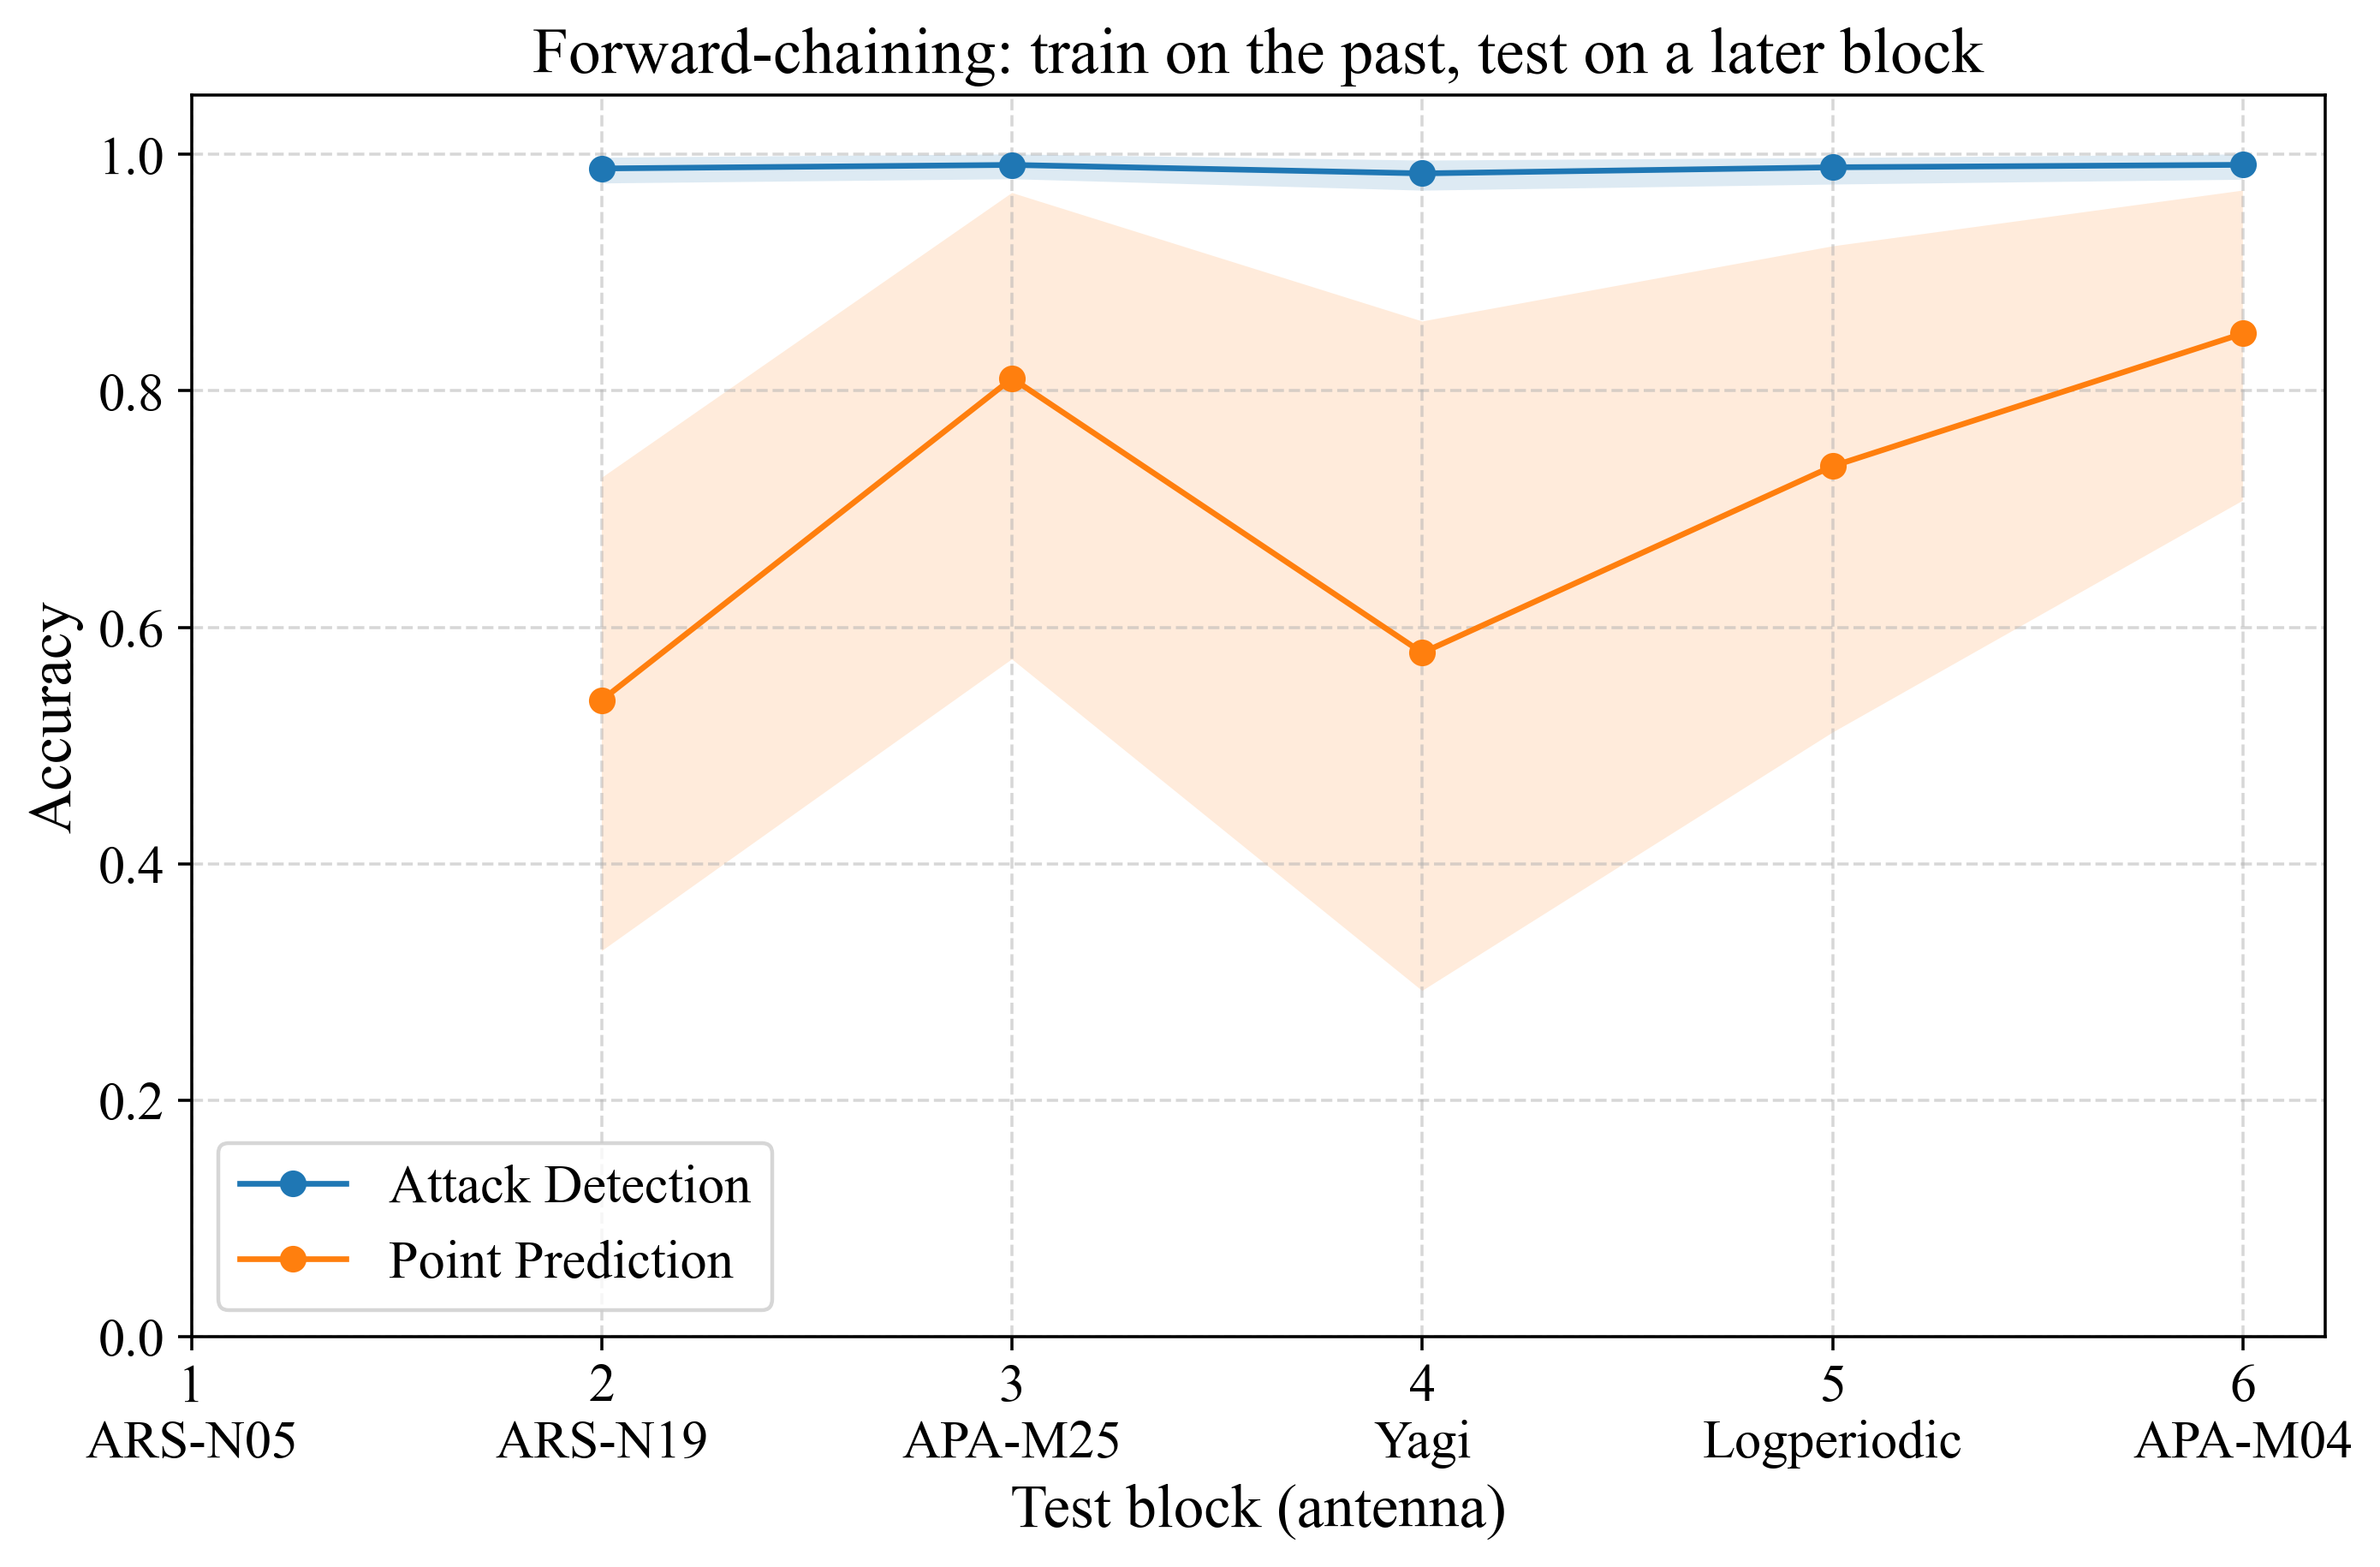

In [7]:
def _plot_forward_chaining(paper: bool):
    fig, ax = plt.subplots(figsize=(9, 6))
    for task_label, sub in forward_chaining_df.groupby("task"):
        ax.plot(sub["test_block"], sub["accuracy"], marker="o", label=task_label)
        ax.fill_between(sub["test_block"], sub["ci_low"], sub["ci_high"], alpha=0.15)
    ax.set_xticks(list(BLOCK_ANTENNA_NAMES.keys()))
    ax.set_xticklabels([f"{b}\n{BLOCK_ANTENNA_NAMES[b]}" for b in BLOCK_ANTENNA_NAMES])
    ax.set_xlabel("Test block (antenna)")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    # F4: paper mode drops the title entirely
    if not paper:
        ax.set_title("Forward-chaining: train on the past, test on a later block")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    return fig

fig_internal = _plot_forward_chaining(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "forward_chaining.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_forward_chaining(paper=True)
fig_paper.savefig(FIGURES_DIR / "forward_chaining.png", bbox_inches="tight")
plt.close(fig_paper)

### Attack-free baseline stability

Median RSSI per sensor per antenna block on attack-free rows only, to document how
stable the environment was over the ~3h experiment.

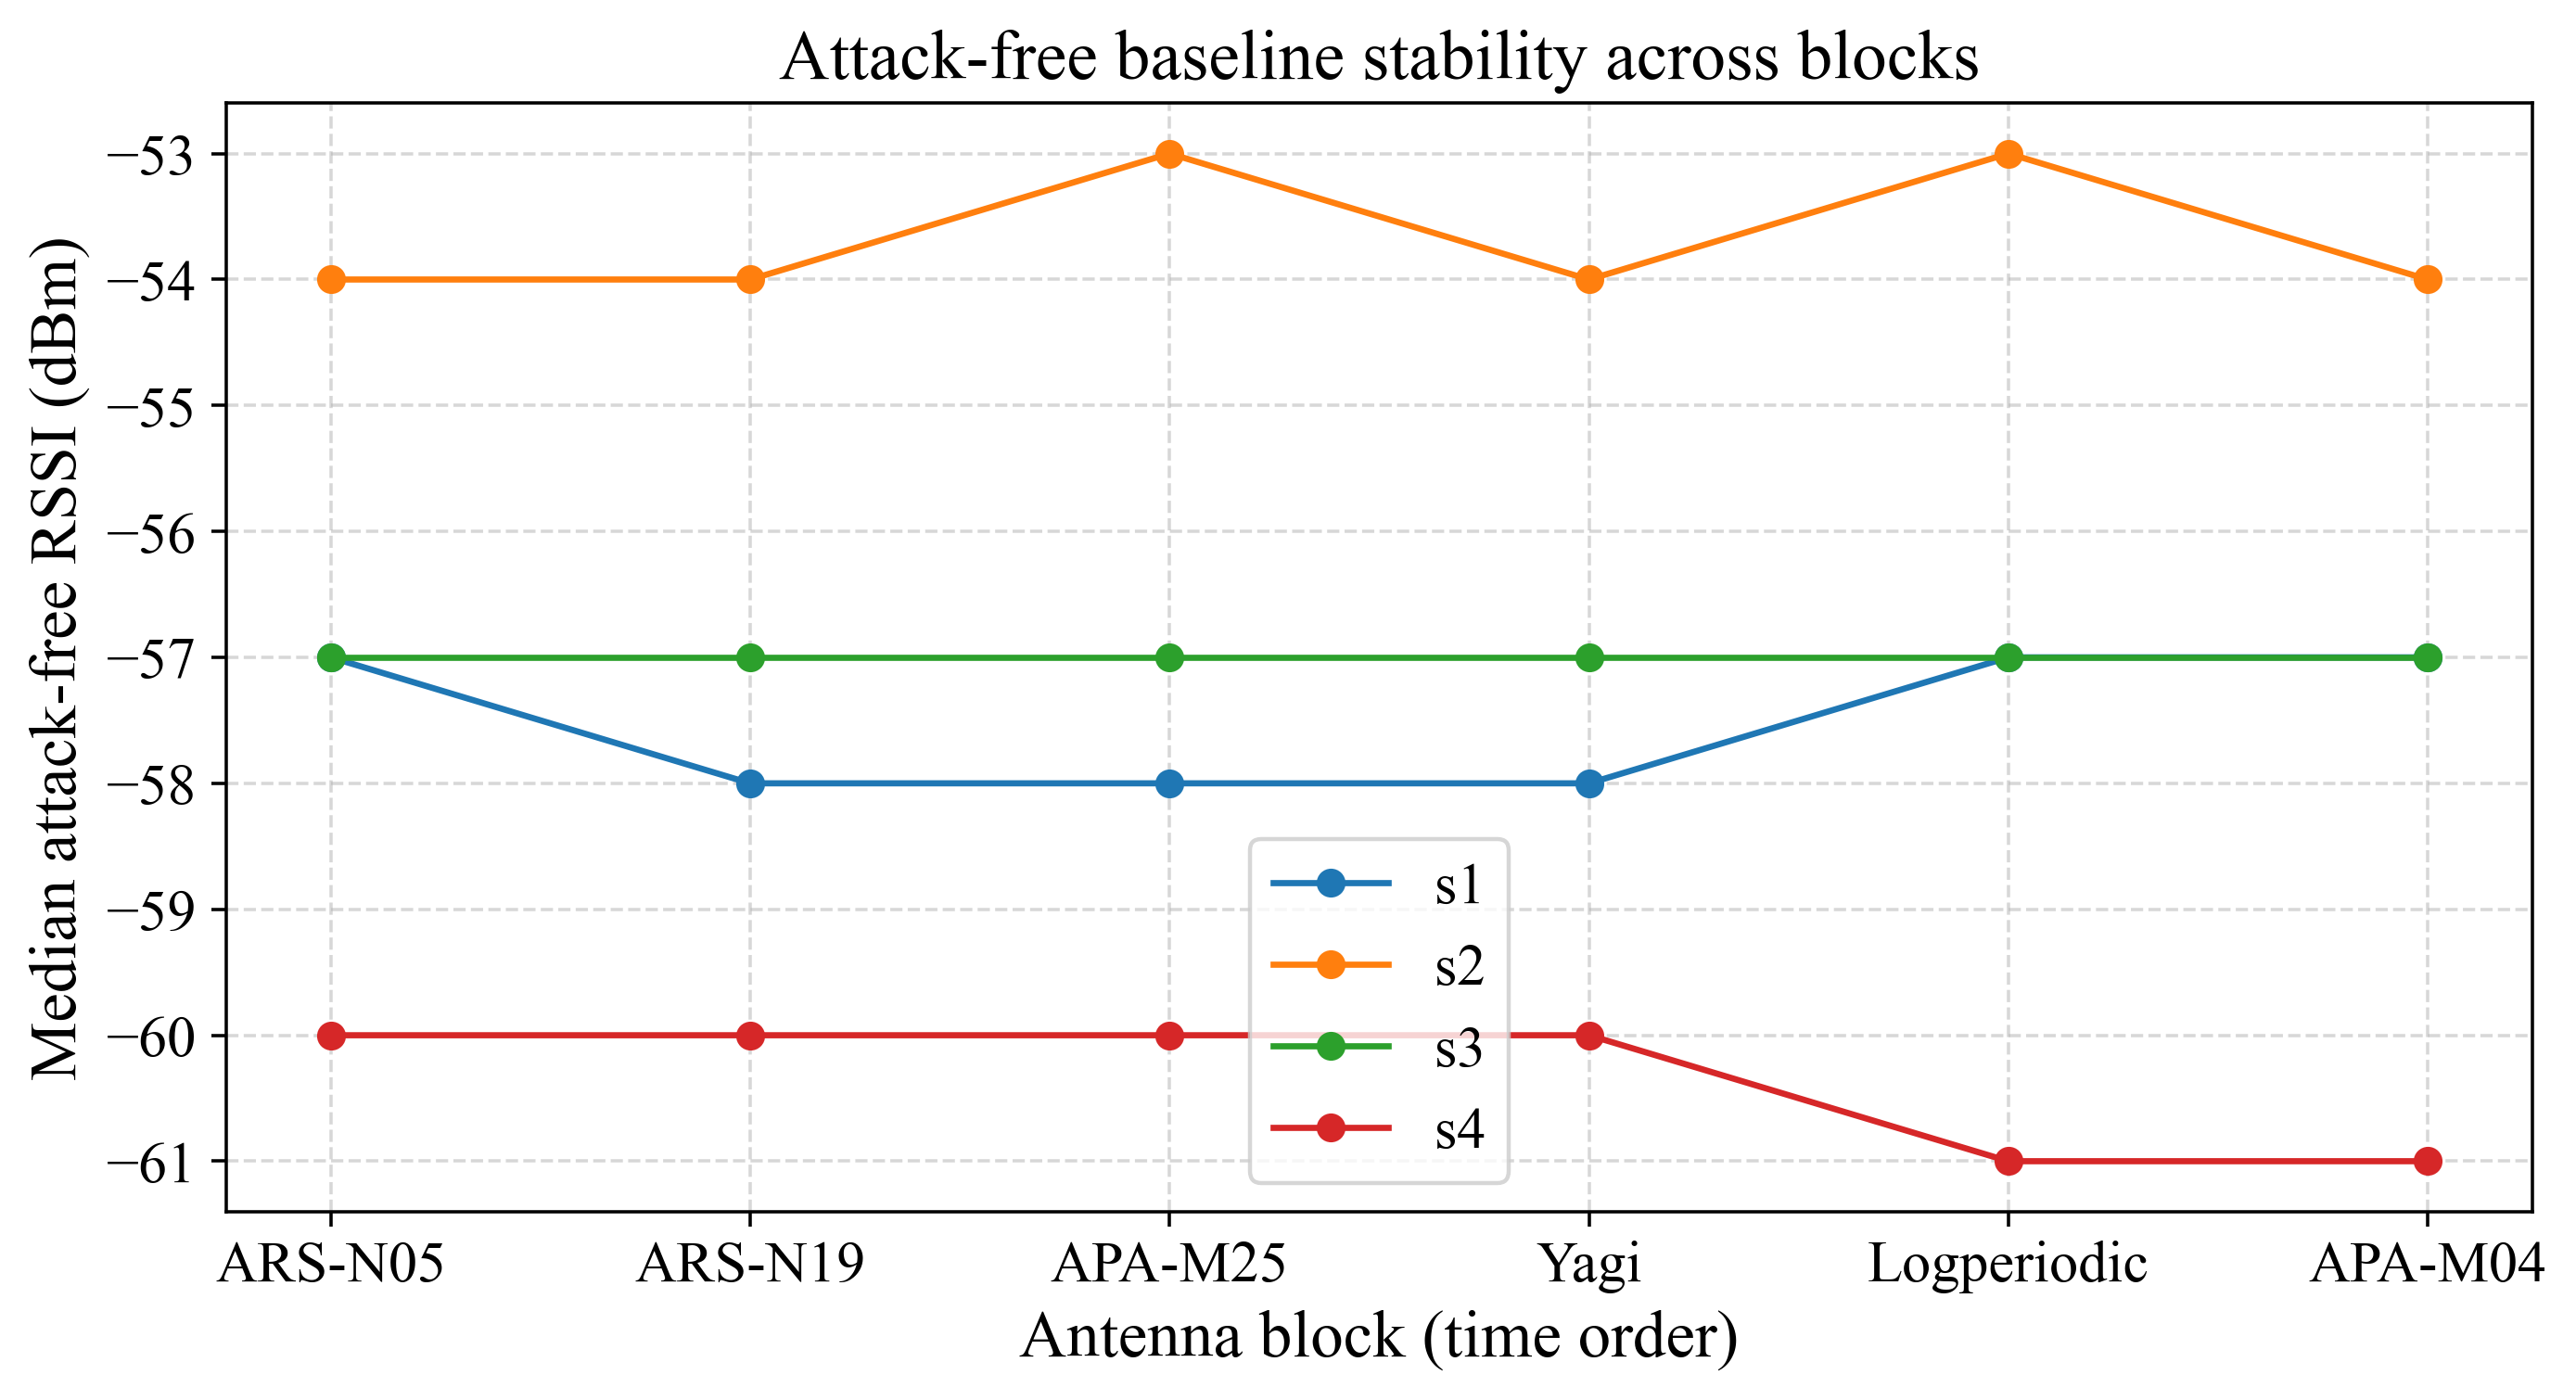

,s1,s2,s3,s4
block,,,,
ARS-N05,-57.0,-54.0,-57.0,-60.0
ARS-N19,-58.0,-54.0,-57.0,-60.0
APA-M25,-58.0,-53.0,-57.0,-60.0
Yagi,-58.0,-54.0,-57.0,-60.0
Logperiodic,-57.0,-53.0,-57.0,-61.0
APA-M04,-57.0,-54.0,-57.0,-61.0


In [8]:
baseline_stability_df = (
    dataset[dataset["attack"] == 0]
    .groupby("block")[ep.FEATURES_BASE]
    .median()
    .rename(index=BLOCK_ANTENNA_NAMES)
)
baseline_stability_df.to_csv(RESULTS_DIR / "baseline_stability.csv")

fig, ax = plt.subplots(figsize=(9, 5))
baseline_stability_df.plot(marker="o", ax=ax)
ax.set_xlabel("Antenna block (time order)")
ax.set_ylabel("Median attack-free RSSI (dBm)")
ax.set_title("Attack-free baseline stability across blocks")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
baseline_stability_df

## 5. V3 — Within-Session Dependence

Quantifies *why* sample-level splitting leaks: lag-1 autocorrelation (temporal) vs.
ICC(1) (cluster/shared-session-mean) of RSSI, on raw scans and on the 5s resampled
series, for attack sessions. Expected pattern: raw autocorrelation ~0, resampled ~0.3
(from imputation), ICC high throughout — **the dependence is a cluster effect, not
temporal autocorrelation**, which is the argument for splitting by session rather than
just avoiding adjacent-row leakage.

In [9]:
raw_grouped = ep.add_groups(raw)
raw_attack = raw_grouped[raw_grouped["attack"] == 1]
dataset_attack = dataset[dataset["attack"] == 1]

device_names = sorted(raw["deviceID"].unique())
sensor_cols = ep.FEATURES_BASE

dep_rows = []
for dev, col in zip(device_names, sensor_cols):
    raw_sub = raw_attack[raw_attack["deviceID"] == dev]
    dep_rows.append({
        "sensor": col, "series": "raw scans",
        "lag1_autocorr": ep.lag1_autocorr_by_session(raw_sub, "value"),
        "icc1": ep.icc1(raw_sub, "value", "session"),
        "n_sessions": raw_sub["session"].nunique(),
    })
    dep_rows.append({
        "sensor": col, "series": "5s resampled",
        "lag1_autocorr": ep.lag1_autocorr_by_session(dataset_attack, col),
        "icc1": ep.icc1(dataset_attack, col, "session"),
        "n_sessions": dataset_attack["session"].nunique(),
    })

dependence_df = pd.DataFrame(dep_rows)
dependence_df.to_csv(RESULTS_DIR / "dependence.csv", index=False)
dependence_df.round(3)

,sensor,series,lag1_autocorr,icc1,n_sessions
0,s1,raw scans,-0.134,0.808,48
1,s1,5s resampled,0.147,0.617,48
2,s2,raw scans,0.012,0.779,48
3,s2,5s resampled,0.300,0.623,48
4,s3,raw scans,0.090,0.881,48
5,s3,5s resampled,0.357,0.646,48
6,s4,raw scans,0.000,0.837,48
7,s4,5s resampled,0.227,0.646,48


## 6. V4 — Cluster Bootstrap Confidence Intervals

95% CIs by resampling **sessions** (never rows) with replacement, 2000 iterations,
seed 0 (`eval_protocol.cluster_bootstrap_ci` — acceptance check #2). V1/V2 already carry
`ci_low`/`ci_high` columns from their own cells above. Here we add the same CI to the
**main-table winners** (`TASK_WINNERS`, the headline numbers from
`02_final_comparison.ipynb`), which requires recomputing their OOF predictions under the
primary protocol — reused below by V5, V6's model choice is independent (fixed Extra
Trees), and F5. For Attack Detection the bootstrap clusters are the full 97 segments
(attack sessions + attack-free gaps); for Point/Antenna they are the 48 attack
sessions.

In [10]:
winner_oof = {}
main_table_ci_rows = []

for task in ep.TASKS_ORDER:
    task_label = ep.TASKS[task]["label"]
    spec = ep.TASKS[task]
    model_name, fs_label = TASK_WINNERS[task]
    feat_cols = ep.FEATURES_BASE if fs_label.startswith("Base") else ep.FEATURES_FE
    is_multiclass = task != "attack"

    sub = dataset[spec["rows"](dataset)].reset_index(drop=True)
    X = sub[feat_cols]
    y = sub[spec["y_col"]]
    outer_cv, groups = ep.get_outer_cv_and_groups("primary", task, sub)

    t0 = time.time()
    res = ep.nested_cv(model_name, X, y, groups, outer_cv, ep.group_kfold_inner_factory(5), is_multiclass=is_multiclass)
    summ = ep.summarize(res, task)
    winner_oof[task] = {"res": res, "sub": sub, "summ": summ}

    cluster_col = "session"
    ci = ep.cluster_bootstrap_ci(res["oof_true"], res["oof_pred"], sub[cluster_col].to_numpy(), n_boot=2000, seed=0)
    main_table_ci_rows.append({
        "task": task_label, "model": model_name, "feature_set": fs_label,
        "pooled_acc": summ["pooled_acc"], "ci_low": ci["ci_low"], "ci_high": ci["ci_high"],
    })
    print(f"[V4] {task_label:<20} {model_name:<20} pooled_acc={summ['pooled_acc']:.3f} "
          f"95% CI=[{ci['ci_low']:.3f}, {ci['ci_high']:.3f}] ({time.time()-t0:.1f}s)")

main_table_ci_df = pd.DataFrame(main_table_ci_rows)
main_table_ci_df.to_csv(RESULTS_DIR / "main_table_ci.csv", index=False)
main_table_ci_df.round(4)

[V4] Attack Detection     KNN                  pooled_acc=0.988 95% CI=[0.983, 0.993] (3.9s)


[V4] Point Prediction     KNN                  pooled_acc=0.743 95% CI=[0.656, 0.821] (2.6s)


[V4] Antenna Prediction   XGBoost              pooled_acc=0.363 95% CI=[0.260, 0.473] (11.0s)


,task,model,feature_set,pooled_acc,ci_low,ci_high
0,Attack Detection,KNN,Base (4),0.9883,0.9833,0.9926
1,Point Prediction,KNN,FE (13),0.7426,0.6562,0.8212
2,Antenna Prediction,XGBoost,Base (4),0.3625,0.2596,0.4729


## 7. V5 — Session-Level Results, Sliding-Window Aggregation & Detection Sensitivity

From the primary-protocol OOF predictions computed above (Point: leave-one-antenna-out;
Antenna: leave-one-point-out; reused from V4), aggregate predictions over a session
(majority vote, n=48) and over causal sliding windows of w consecutive rows.

**F3 fix:** the false-alarm rate is no longer reported alone. For w in {1,2,3} we now
also report, on the Attack Detection OOF predictions: the **attack-session detection
rate** (share of the 48 attack sessions with >=1 alarm), the **median detection delay**
in seconds from session start to first alarm, and the **row-level recall** under the
same full-window alarm rule (`eval_protocol.attack_detection_sensitivity`).

In [11]:
session_level_rows = []
window_rows = []

for task in ["point", "antenna"]:
    task_label = ep.TASKS[task]["label"]
    res = winner_oof[task]["res"]
    sub = winner_oof[task]["sub"]

    acc, session_tbl = ep.session_level_accuracy(res["oof_true"], res["oof_pred"], sub["session"].to_numpy())
    session_level_rows.append({"task": task_label, "level": "session majority vote (n=48)", "accuracy": acc, "n": len(session_tbl)})

    sw = ep.sliding_window_accuracy(res["oof_true"], res["oof_pred"], sub["session"].to_numpy(), window_sizes=(1, 2, 3, 6, 12))
    for w, a in sw.items():
        window_rows.append({"task": task_label, "window": w, "accuracy": a})

# sample-level (window=1, i.e. no aggregation) accuracy for reference
for task in ["point", "antenna"]:
    task_label = ep.TASKS[task]["label"]
    session_level_rows.append({
        "task": task_label, "level": "sample level (no aggregation)",
        "accuracy": winner_oof[task]["summ"]["pooled_acc"], "n": len(winner_oof[task]["res"]["oof_true"]),
    })

session_level_df = pd.DataFrame(session_level_rows)
window_df = pd.DataFrame(window_rows)

# Attack Detection: false-alarm rate per hour + F3 detection sensitivity
attack_res = winner_oof["attack"]["res"]
attack_sub = winner_oof["attack"]["sub"]
fa_rates, fa_hours = ep.false_alarm_rate_per_hour(
    attack_res["oof_true"], attack_res["oof_pred"], attack_sub["session"].to_numpy(),
    freq_seconds=5, window_sizes=(1, 2, 3),
)
sensitivity = ep.attack_detection_sensitivity(
    attack_res["oof_true"], attack_res["oof_pred"], attack_sub["session"].to_numpy(),
    freq_seconds=5, window_sizes=(1, 2, 3),
)
false_alarm_df = pd.DataFrame([
    {
        "window": w, "false_alarms_per_hour": fa_rates[w],
        "detection_rate": sensitivity[w]["detection_rate"],
        "median_delay_s": sensitivity[w]["median_delay_s"],
        "row_recall": sensitivity[w]["row_recall"],
        "n_attack_sessions": sensitivity[w]["n_attack_sessions"],
        "n_detected": sensitivity[w]["n_detected"],
    }
    for w in (1, 2, 3)
])
false_alarm_df.attrs["attack_free_hours"] = fa_hours

window_aggregation_df = pd.concat([
    session_level_df.assign(kind="session_level"),
    window_df.assign(kind="sliding_window"),
    false_alarm_df.assign(kind="false_alarm_and_detection", task="Attack Detection"),
], ignore_index=True)
window_aggregation_df.to_csv(RESULTS_DIR / "window_aggregation.csv", index=False)

print(f"Attack-free duration in OOF set: {fa_hours:.3f} hours")
print(session_level_df.round(4))
print(window_df.round(4))
print(false_alarm_df.round(3))

Attack-free duration in OOF set: 2.167 hours
                 task                          level  accuracy    n
0    Point Prediction   session majority vote (n=48)    0.8958   48
1  Antenna Prediction   session majority vote (n=48)    0.3542   48
2    Point Prediction  sample level (no aggregation)    0.7426  571
3  Antenna Prediction  sample level (no aggregation)    0.3625  571
                 task  window  accuracy
0    Point Prediction       1    0.7426
1    Point Prediction       2    0.7426
2    Point Prediction       3    0.7846
3    Point Prediction       6    0.7846
4    Point Prediction      12    0.8179
5  Antenna Prediction       1    0.3625
6  Antenna Prediction       2    0.3625
7  Antenna Prediction       3    0.3765
8  Antenna Prediction       6    0.3765
9  Antenna Prediction      12    0.4046
   window  false_alarms_per_hour  detection_rate  median_delay_s  row_recall  \
0       1                  4.615             1.0             0.0       0.974   
1       2      

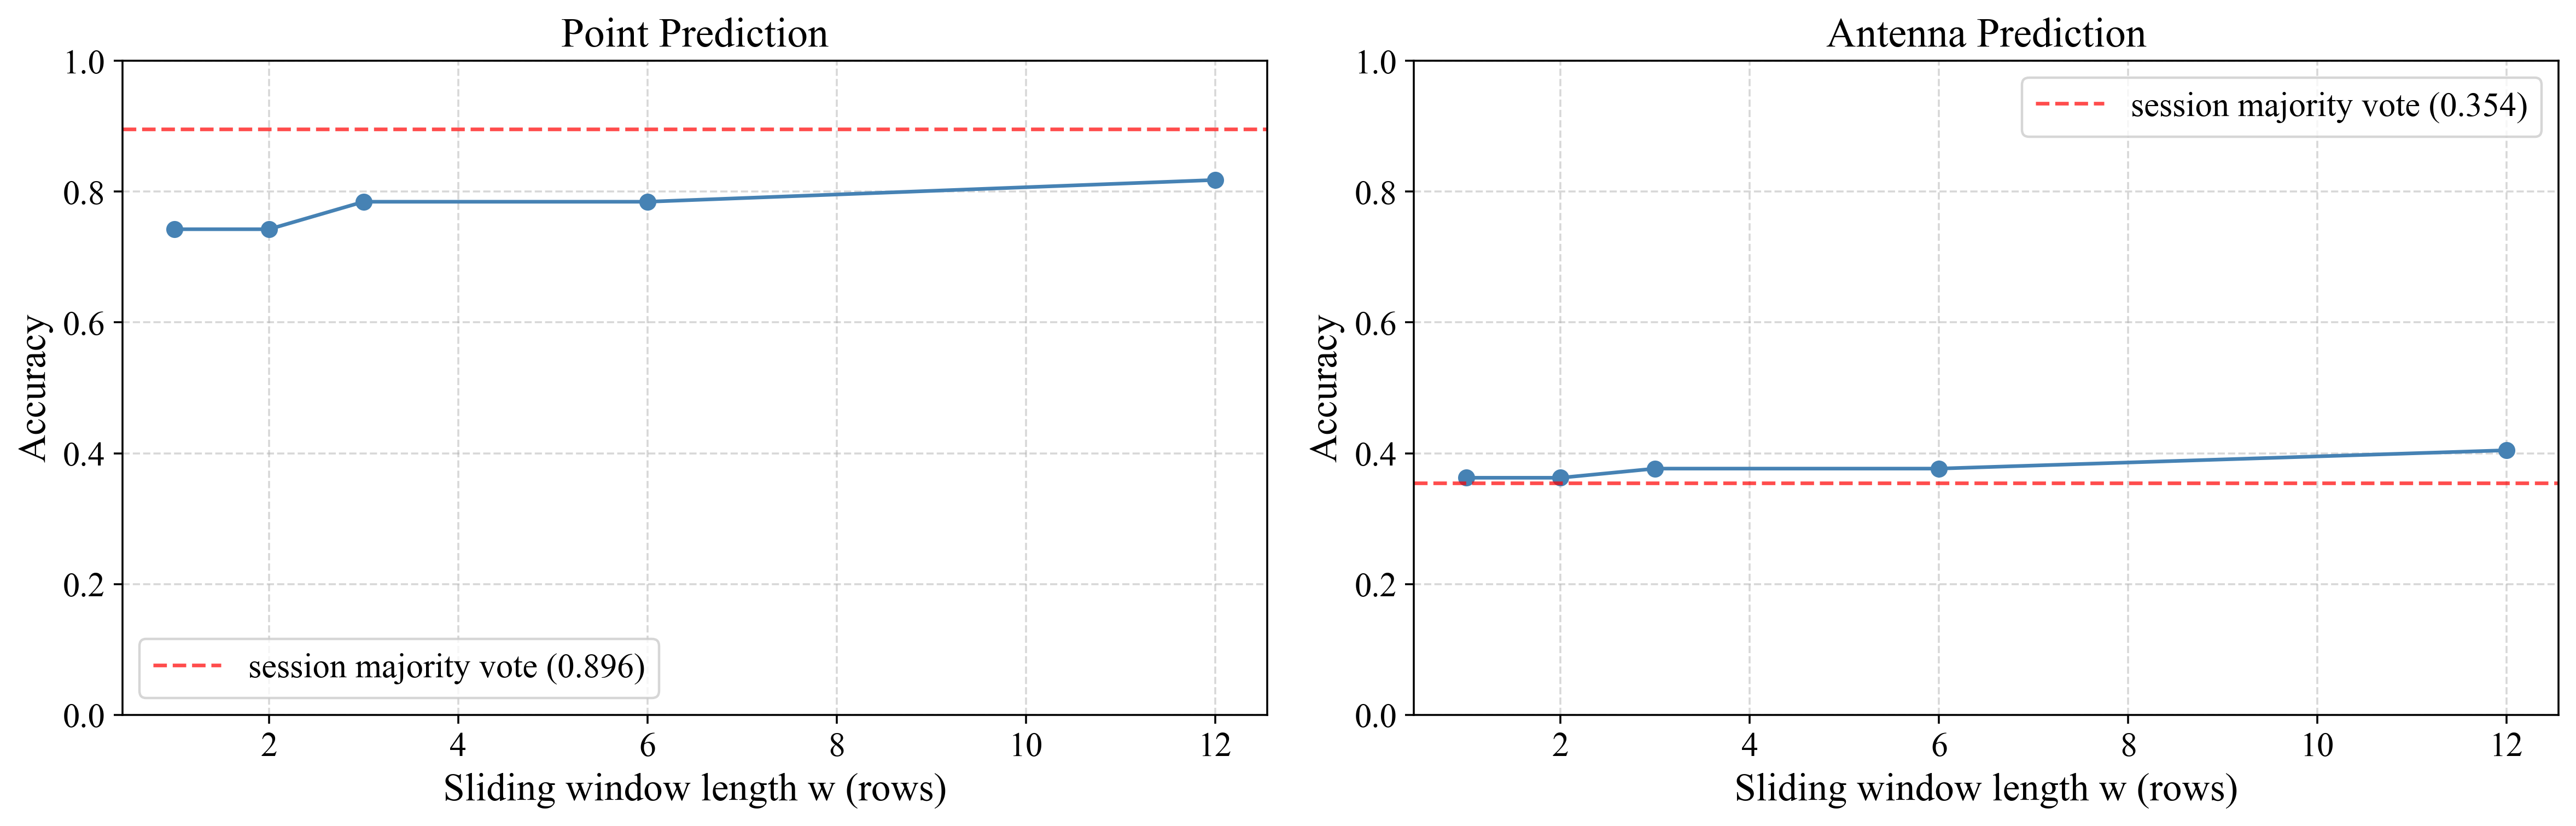

In [12]:
def _plot_window_aggregation(paper: bool):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for task, ax in zip(["point", "antenna"], axes):
        task_label = ep.TASKS[task]["label"]
        sub = window_df[window_df.task == task_label].sort_values("window")
        ax.plot(sub["window"], sub["accuracy"], marker="o", color="#4682B4")
        session_acc = session_level_df[(session_level_df.task == task_label) & (session_level_df.level.str.startswith("session"))]["accuracy"].iloc[0]
        ax.axhline(session_acc, color="red", linestyle="--", alpha=0.7, label=f"session majority vote ({session_acc:.3f})")
        ax.set_xlabel("Sliding window length w (rows)")
        ax.set_ylabel("Accuracy")
        ax.set_title("" if paper else task_label)
        ax.set_ylim(0, 1.0)
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    return fig

fig_internal = _plot_window_aggregation(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "window_aggregation.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_window_aggregation(paper=True)
fig_paper.savefig(FIGURES_DIR / "window_aggregation.png", bbox_inches="tight")
plt.close(fig_paper)

## 8. V6 — Session-Level Permutation Test

Null hypothesis: labels are unrelated to the RSSI profile. Labels are permuted **at the
session level** (each session's whole label reassigned to all its rows, preserving
within-session structure — acceptance check #3); for Antenna, the permutation is
restricted to sessions sharing the same point, so spatial position cannot explain the
result. 1000 permutations, primary protocol, fixed Extra Trees (300 trees) — a fixed,
untuned model chosen independently of any hold-out design, so F1 does not apply here.
This cell is the longest-running in the notebook (~15-25 min per task).

In [13]:
def et_factory():
    return ep.ExtraTreesClassifier(n_estimators=300, random_state=ep.RANDOM_STATE)

perm_results = {}
for task, within_col in [("point", None), ("antenna", "point")]:
    task_label = ep.TASKS[task]["label"]
    spec = ep.TASKS[task]
    sub = dataset[spec["rows"](dataset)].reset_index(drop=True)
    X = sub[ep.FEATURES_FE]
    y = sub[spec["y_col"]].to_numpy()
    sessions = sub["session"].to_numpy()
    outer_cv, groups = ep.get_outer_cv_and_groups("primary", task, sub)
    within = sub[within_col].to_numpy() if within_col else None

    t0 = time.time()
    res = ep.session_permutation_test(
        X, y, sessions, groups, outer_cv, within=within,
        n_perm=1000, seed=0, model_factory=et_factory, n_jobs=1,
    )
    perm_results[task] = res
    print(f"[V6] {task_label:<20} observed={res['observed']:.4f} null_mean={res['null_mean']:.4f} "
          f"null_p95={res['null_p95']:.4f} p={res['p_value']:.4f} ({time.time()-t0:.1f}s)")

permutation_tests_df = pd.DataFrame([
    {
        "task": ep.TASKS[task]["label"], "observed_accuracy": r["observed"],
        "null_mean": r["null_mean"], "null_p95": r["null_p95"], "p_value": r["p_value"],
        "n_permutations": len(r["null_scores"]),
    }
    for task, r in perm_results.items()
])
permutation_tests_df.to_csv(RESULTS_DIR / "permutation_tests.csv", index=False)
permutation_tests_df

[V6] Point Prediction     observed=0.7356 null_mean=0.1022 null_p95=0.1804 p=0.0010 (961.2s)


[V6] Antenna Prediction   observed=0.3363 null_mean=0.1698 null_p95=0.2434 p=0.0020 (1330.7s)


,task,observed_accuracy,null_mean,null_p95,p_value,n_permutations
0,Point Prediction,0.735552,0.102238,0.180385,0.000999,1000
1,Antenna Prediction,0.336252,0.169809,0.243433,0.001998,1000


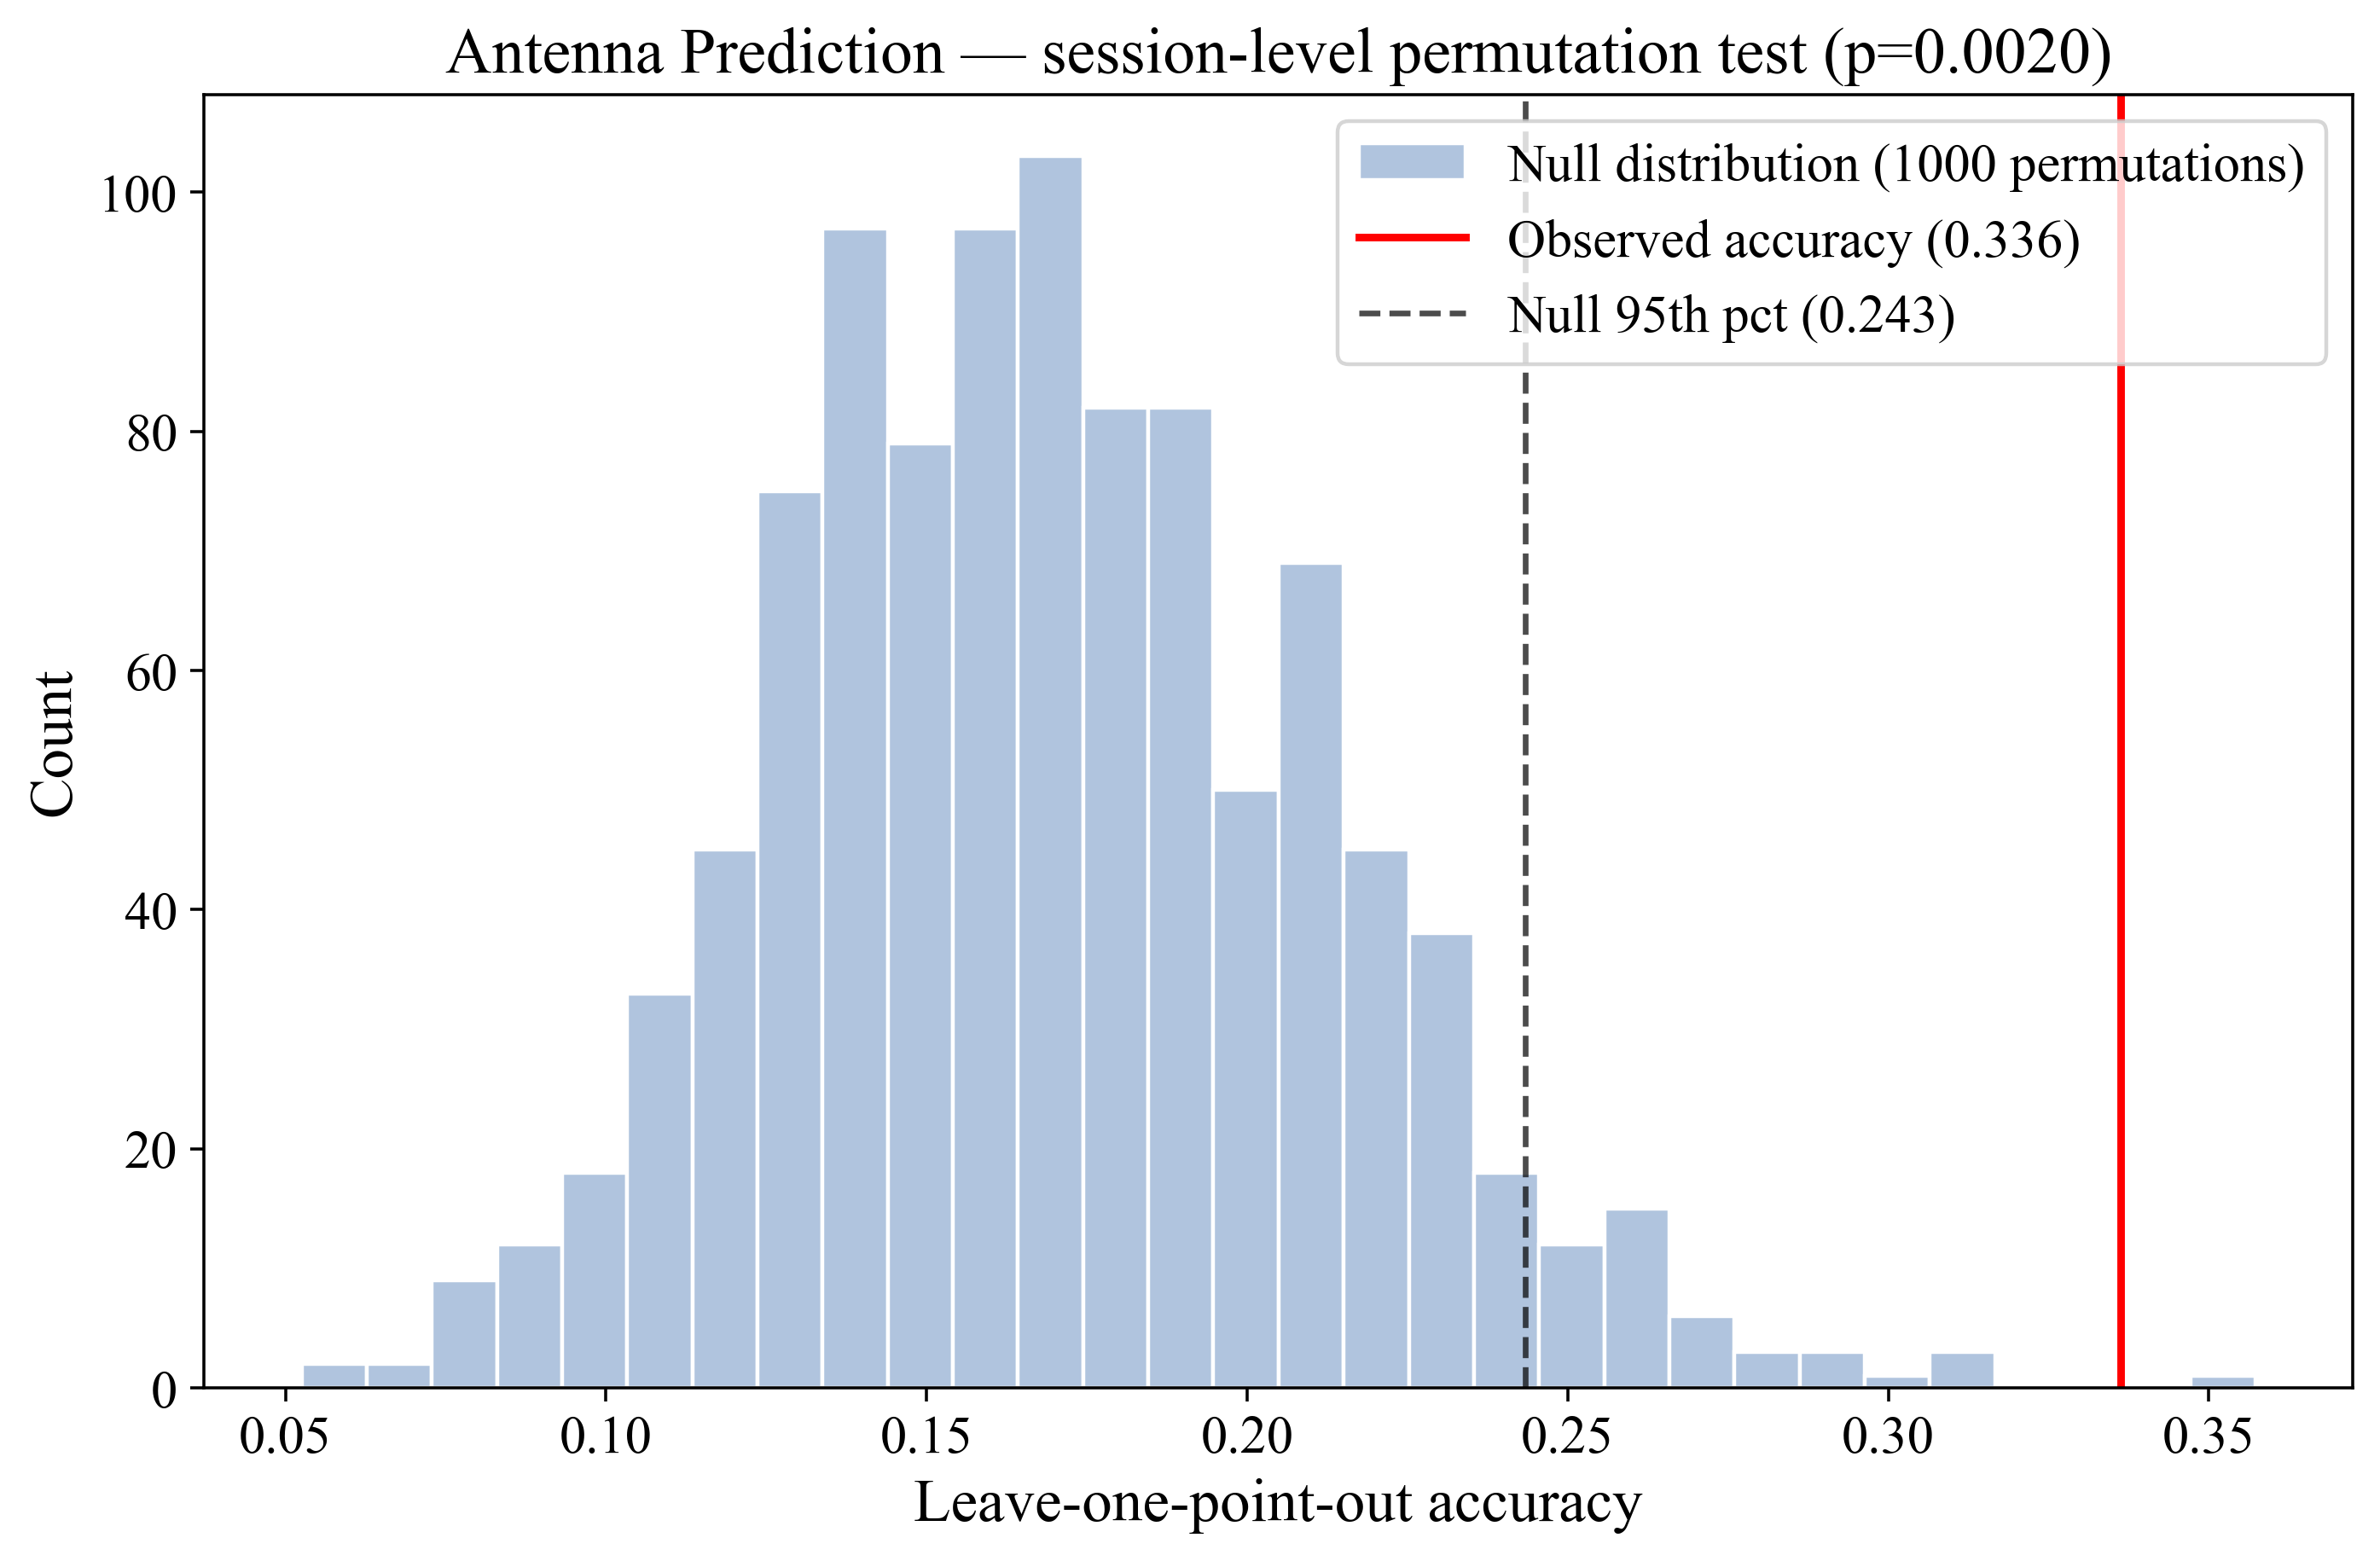

In [14]:
def _plot_permutation_antenna(paper: bool):
    fig, ax = plt.subplots(figsize=(9, 6))
    res = perm_results["antenna"]
    ax.hist(res["null_scores"], bins=30, color="#B0C4DE", edgecolor="white", label="Null distribution (1000 permutations)")
    ax.axvline(res["observed"], color="red", linestyle="-", linewidth=2, label=f"Observed accuracy ({res['observed']:.3f})")
    ax.axvline(res["null_p95"], color="black", linestyle="--", alpha=0.7, label=f"Null 95th pct ({res['null_p95']:.3f})")
    ax.set_xlabel("Leave-one-point-out accuracy")
    ax.set_ylabel("Count")
    if not paper:
        ax.set_title(f"Antenna Prediction — session-level permutation test (p={res['p_value']:.4f})")
    ax.legend()
    plt.tight_layout()
    return fig

fig_internal = _plot_permutation_antenna(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "permutation_antenna.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_permutation_antenna(paper=True)
fig_paper.savefig(FIGURES_DIR / "permutation_antenna.png", bbox_inches="tight")
plt.close(fig_paper)

## 9. V7 — No-Imputation Sensitivity Variants

**F2 fix:** two variants are now reported, not just the `dropna()` grid:

- **dropna_5s** (as before): 5s grid, no nearest-neighbour interpolation
  (`eval_protocol.build_dataset(..., impute="none")`) — keeps only grid points where
  every sensor already had a direct reading.
- **scan_cycle** (option a, new): `eval_protocol.build_dataset_scan_cycle` — for each
  scan of the anchor sensor, takes the nearest scan of every other sensor within
  +/-3.6s and drops the row if any sensor has no scan in that window. No resampling
  grid, no imputation.

Both rerun the full nested primary protocol for each task's *main-table* winning
model/feature-set combination (`TASK_WINNERS`).

In [15]:
raw_v7 = ep.load_raw()

dataset_dropna, info_dropna = ep.build_dataset(raw_v7, freq="5s", impute="none")
dataset_dropna = ep.add_fe(dataset_dropna)

dataset_scancycle, info_scancycle = ep.build_dataset_scan_cycle(raw_v7, tolerance_seconds=3.6)
dataset_scancycle = ep.add_fe(dataset_scancycle)

print(f"Imputed (main) dataset: {info.n_rows} rows, {info.n_attack_rows} attack rows, {info.n_sessions_attack} attack sessions")
print(f"dropna_5s variant:      {info_dropna.n_rows} rows, {info_dropna.n_attack_rows} attack rows, {info_dropna.n_sessions_attack} attack sessions")
print(f"scan_cycle variant:     {info_scancycle.n_rows} rows, {info_scancycle.n_attack_rows} attack rows, {info_scancycle.n_sessions_attack} attack sessions")

VARIANTS = {"dropna_5s": (dataset_dropna, info_dropna), "scan_cycle": (dataset_scancycle, info_scancycle)}

noimpute_rows = []
for task in ep.TASKS_ORDER:
    task_label = ep.TASKS[task]["label"]
    spec = ep.TASKS[task]
    model_name, fs_label = TASK_WINNERS[task]
    feat_cols = ep.FEATURES_BASE if fs_label.startswith("Base") else ep.FEATURES_FE
    is_multiclass = task != "attack"
    imputed_acc = table1_df.loc[model_name, f"{task_label} Pooled Acc ({'Base' if fs_label.startswith('Base') else 'FE'})"]

    for variant_name, (variant_dataset, variant_info) in VARIANTS.items():
        sub_v = variant_dataset[spec["rows"](variant_dataset)].reset_index(drop=True)
        X_v, y_v = sub_v[feat_cols], sub_v[spec["y_col"]]
        outer_cv_v, groups_v = ep.get_outer_cv_and_groups("primary", task, sub_v)

        t0 = time.time()
        res_v = ep.nested_cv(model_name, X_v, y_v, groups_v, outer_cv_v, ep.group_kfold_inner_factory(5), is_multiclass=is_multiclass)
        summ_v = ep.summarize(res_v, task)

        noimpute_rows.append({
            "task": task_label, "model": model_name, "feature_set": fs_label, "variant": variant_name,
            "pooled_acc_imputed": imputed_acc, "pooled_acc_variant": summ_v["pooled_acc"],
            "delta": summ_v["pooled_acc"] - imputed_acc,
            "n_rows_imputed": info.n_rows if task == "attack" else info.n_attack_rows,
            "n_rows_variant": variant_info.n_rows if task == "attack" else variant_info.n_attack_rows,
            "n_attack_sessions_imputed": info.n_sessions_attack,
            "n_attack_sessions_variant": variant_info.n_sessions_attack,
        })
        print(f"[V7 {variant_name:<10}] {task_label:<20} {model_name:<20} "
              f"imputed={imputed_acc:.3f} variant={summ_v['pooled_acc']:.3f} ({time.time()-t0:.1f}s)")

no_imputation_df = pd.DataFrame(noimpute_rows)
no_imputation_df.to_csv(RESULTS_DIR / "no_imputation_variant.csv", index=False)
no_imputation_df.round(4)

Imputed (main) dataset: 2131 rows, 571 attack rows, 48 attack sessions
dropna_5s variant:      442 rows, 116 attack rows, 37 attack sessions
scan_cycle variant:     1277 rows, 320 attack rows, 48 attack sessions


[V7 dropna_5s ] Attack Detection     KNN                  imputed=0.988 variant=0.975 (4.1s)


[V7 scan_cycle] Attack Detection     KNN                  imputed=0.988 variant=0.998 (3.0s)


[V7 dropna_5s ] Point Prediction     KNN                  imputed=0.743 variant=0.750 (1.8s)


[V7 scan_cycle] Point Prediction     KNN                  imputed=0.743 variant=0.762 (2.1s)


[V7 dropna_5s ] Antenna Prediction   XGBoost              imputed=0.363 variant=0.388 (6.3s)


[V7 scan_cycle] Antenna Prediction   XGBoost              imputed=0.363 variant=0.312 (8.7s)


,task,model,feature_set,variant,pooled_acc_imputed,pooled_acc_variant,delta,n_rows_imputed,n_rows_variant,n_attack_sessions_imputed,n_attack_sessions_variant
0,Attack Detection,KNN,Base (4),dropna_5s,0.9883,0.9751,-0.0132,2131,442,48,37
1,Attack Detection,KNN,Base (4),scan_cycle,0.9883,0.9984,0.0102,2131,1277,48,48
2,Point Prediction,KNN,FE (13),dropna_5s,0.7426,0.7500,0.0074,571,116,48,37
3,Point Prediction,KNN,FE (13),scan_cycle,0.7426,0.7625,0.0199,571,320,48,48
4,Antenna Prediction,XGBoost,Base (4),dropna_5s,0.3625,0.3879,0.0254,571,116,48,37
5,Antenna Prediction,XGBoost,Base (4),scan_cycle,0.3625,0.3125,-0.0500,571,320,48,48


## 10. F5 — Localization Error in Metres

Using the Point Prediction OOF predictions of the main-table winning model (primary
protocol, leave-one-antenna-out; reused from V4), `eval_protocol.point_distance_m`
(chord on the 11m circle, 45 deg spacing, points numbered counter-clockwise from the
east) gives the localization error per prediction. Reports sample-level and
session-majority-vote mean/median error, the share of exact/adjacent(8.42m)/farther
predictions, and a session-level cluster-bootstrap 95% CI for the mean error.

In [16]:
point_res = winner_oof["point"]["res"]
point_sub = winner_oof["point"]["sub"]

loc_summary = ep.localization_error_summary(point_res["oof_true"], point_res["oof_pred"], point_sub["session"].to_numpy())

def _mean_error_metric(yt, yp):
    return float(np.mean([ep.point_distance_m(int(t), int(p)) for t, p in zip(yt, yp)]))

loc_ci = ep.cluster_bootstrap_ci(
    point_res["oof_true"], point_res["oof_pred"], point_sub["session"].to_numpy(),
    metric_fn=_mean_error_metric, n_boot=2000, seed=0,
)

localization_error_df = pd.DataFrame([
    {
        "level": "sample", "n": loc_summary["n"],
        "mean_error_m": loc_summary["mean_error_m"], "median_error_m": loc_summary["median_error_m"],
        "share_exact": loc_summary["share_exact"], "share_adjacent_8.42m": loc_summary["share_adjacent"],
        "share_farther": loc_summary["share_farther"],
        "ci_low_mean_error_m": loc_ci["ci_low"], "ci_high_mean_error_m": loc_ci["ci_high"],
    },
    {
        "level": "session majority vote (n=48)", "n": loc_summary["session"]["n"],
        "mean_error_m": loc_summary["session"]["mean_error_m"], "median_error_m": loc_summary["session"]["median_error_m"],
        "share_exact": loc_summary["session"]["share_exact"], "share_adjacent_8.42m": loc_summary["session"]["share_adjacent"],
        "share_farther": loc_summary["session"]["share_farther"],
        "ci_low_mean_error_m": None, "ci_high_mean_error_m": None,
    },
])
localization_error_df.to_csv(RESULTS_DIR / "localization_error_m.csv", index=False)
print(f"Model: {TASK_WINNERS['point'][0]} ({TASK_WINNERS['point'][1]}), primary protocol (leave-one-antenna-out)")
localization_error_df.round(4)

Model: KNN (FE (13)), primary protocol (leave-one-antenna-out)


,level,n,mean_error_m,median_error_m,share_exact,share_adjacent_8.42m,share_farther,ci_low_mean_error_m,ci_high_mean_error_m
0,sample,571,3.3228,0.0,0.7426,0.1419,0.1156,2.3802,4.2921
1,session majority vote (n=48),48,1.0257,0.0,0.8958,0.0833,0.0208,NaN,NaN


## 11. Acceptance Checks Recap

1. V1 test rows/sessions never appear in any fit or inner-CV split: asserted inline in
   every `locked_holdout_eval` call (`assert_no_session_overlap` + per-inner-fold
   `_assert_no_group_overlap`) and in the V2 forward-chaining loop. F1's dev-only model
   ranking (`select_best_model_on_dev`) additionally cannot see test data by
   construction — its signature has no test-set parameter.
2. Every CI is computed by resampling sessions, never rows: `cluster_bootstrap_ci`
   resamples whole clusters (sessions/segments) with replacement — see its
   implementation in `eval_protocol.py`.
3. The Antenna permutation test keeps each session's label constant across its rows and
   permutes only within the same point: enforced by `session_label_permutation` (the
   `within=sub["point"]` argument in section 8) and spot-checked below.
4. This notebook runs clean top-to-bottom (`jupyter nbconvert --execute`).

In [17]:
# Spot-check acceptance check #3: within a permutation, every row of a session
# has the same permuted label, and sessions sharing a point permute only among themselves.
sub_check = dataset[dataset["attack"] == 1].reset_index(drop=True)
rng_check = np.random.default_rng(123)
y_perm_check = ep.session_label_permutation(
    sub_check["antenna"].to_numpy(), sub_check["session"].to_numpy(), rng_check,
    within=sub_check["point"].to_numpy(),
)
check_df = pd.DataFrame({"session": sub_check["session"], "point": sub_check["point"], "y_perm": y_perm_check})
per_session_constant = check_df.groupby("session")["y_perm"].nunique().eq(1).all()
per_session_point_preserved = (check_df.groupby("session")["point"].first() == dataset[dataset.attack==1].groupby("session")["point"].first()).all()
print("Every session's permuted label is constant across its rows:", per_session_constant)
print("Each session's own point (stratum) is unchanged by the permutation:", per_session_point_preserved)
assert per_session_constant and per_session_point_preserved
print("Acceptance check #3 verified.")

# Spot-check F1: selected_on_dev is set for exactly one model per task/design.
counts = final_holdout_df.groupby(["task", "design"])["selected_on_dev"].sum()
assert (counts == 1).all(), counts
print("F1 check: exactly one model flagged selected_on_dev per task/design.")
print(counts)

Every session's permuted label is constant across its rows: True
Each session's own point (stratum) is unchanged by the permutation: True
Acceptance check #3 verified.
F1 check: exactly one model flagged selected_on_dev per task/design.
task                design                         
Antenna Prediction  V1b balanced session hold-out      1
Attack Detection    V1a temporal (block 6 held out)    1
                    V1b balanced session hold-out      1
Point Prediction    V1a temporal (block 6 held out)    1
                    V1b balanced session hold-out      1
Name: selected_on_dev, dtype: int64
